<a href="https://colab.research.google.com/github/boradedeepak/Projects/blob/main/Project_loan_approval_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Librarires

In [218]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns

Importing dataset

In [219]:
df = pd.read_csv('/content/loan_approval_dataset.csv')
x = df.iloc[:, -1].values
y = df.iloc[:, -1].values

Data preprocessing

In [220]:
#Display the first and last five records

df.head()


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [221]:
df.tail()


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved
4268,4269,1,Graduate,No,9200000,29700000,10,607,17800000,11800000,35700000,12000000,Approved


In [222]:
#Check dataset dimensions

df.shape

(4269, 13)

In [223]:
#Display column names

df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [224]:
# Find Incorrect Data Types  #NEED HELP

#Extra Spaces in Column Names

df.columns = df.columns.str.strip()
print("Cleaned Column Names:", df.columns.tolist())



Cleaned Column Names: ['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']


In [225]:
#Identify numerical and categorical features
numerical = df.select_dtypes(include=np.number).columns.tolist()
categorical = df.select_dtypes(exclude=np.number).columns.tolist()
print("numerical feature:", numerical)
print("categorical feature:", categorical)


numerical feature: ['loan_id', 'no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
categorical feature: ['education', 'self_employed', 'loan_status']


In [226]:
# Identify the target variable = 'loan_status'
#Missing Values

df.isnull().sum()

,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


In [227]:
#datatypes
df.dtypes

,0
loan_id,int64
no_of_dependents,int64
education,object
self_employed,object
income_annum,int64
loan_amount,int64
loan_term,int64
cibil_score,int64
residential_assets_value,int64
commercial_assets_value,int64


In [228]:
# Duplicate Records
df.duplicated().sum()

np.int64(0)

Exploratory Data Analysis (EDA)

In [229]:
# Dataset Summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [230]:
#Descriptive Statistics
df.describe()
# df.describe().transpose()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


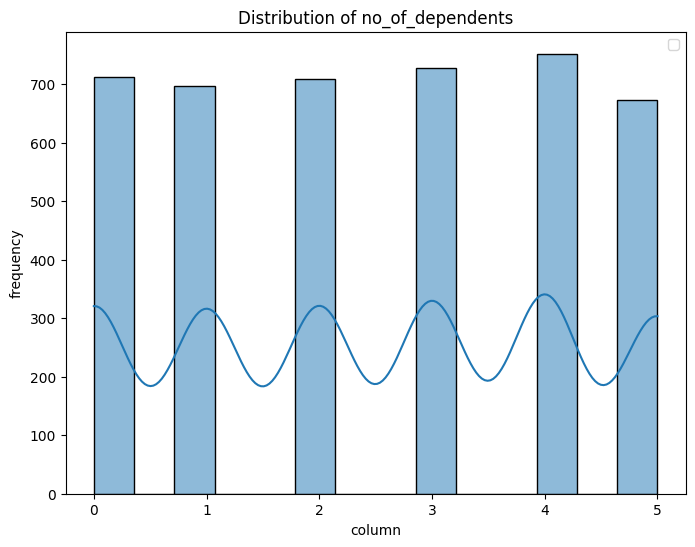

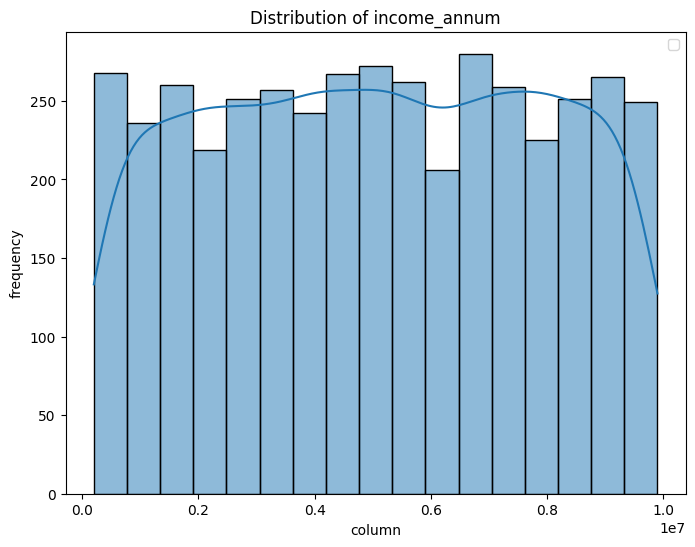

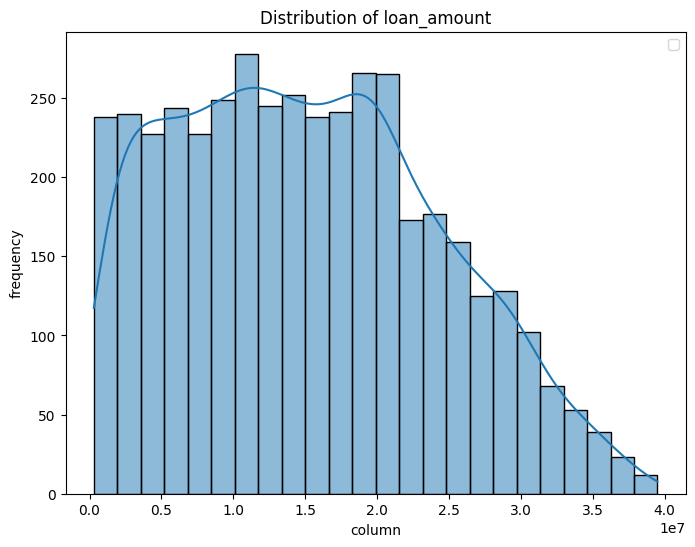

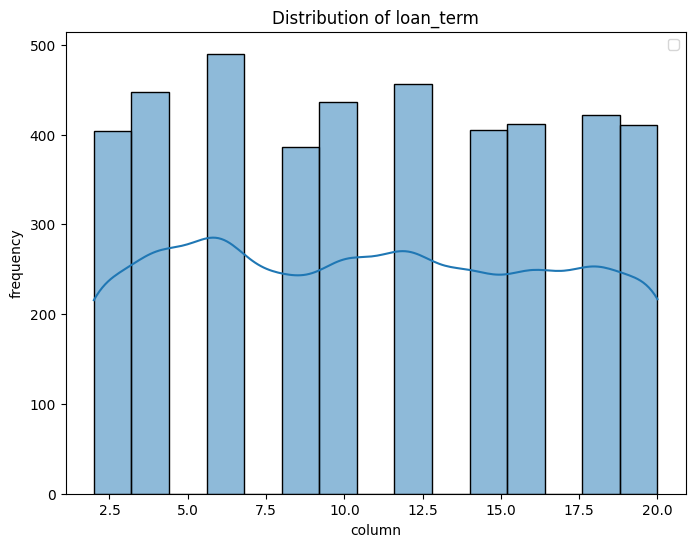

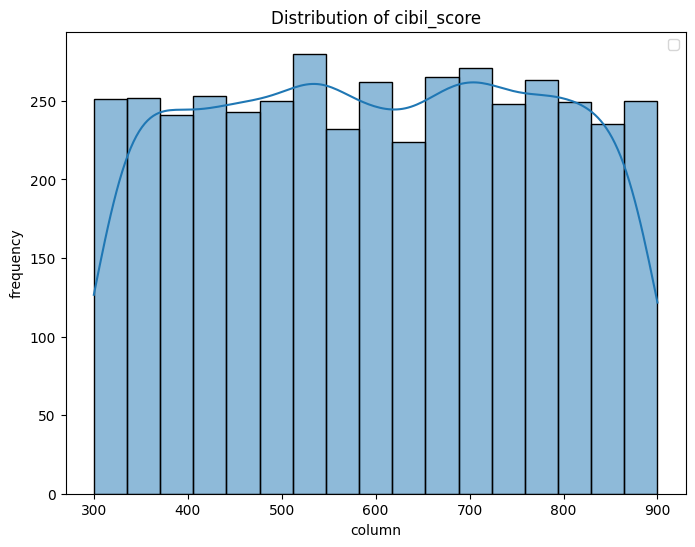

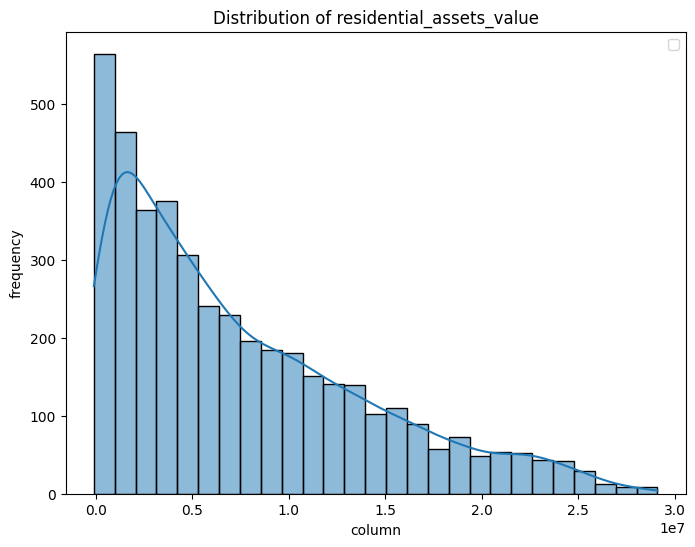

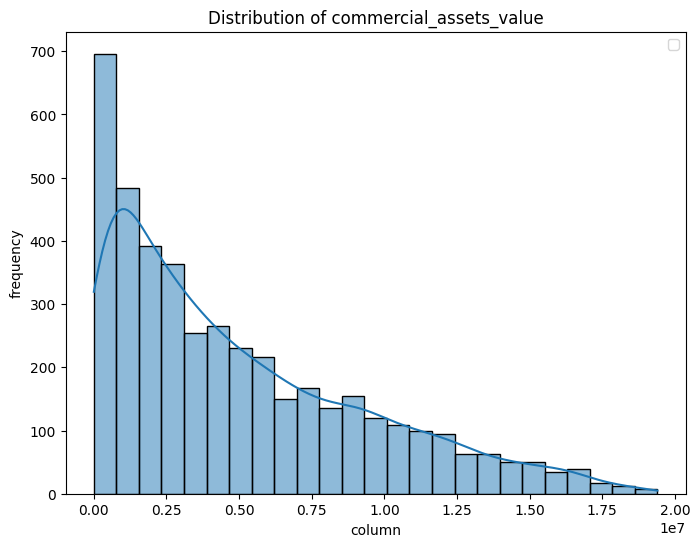

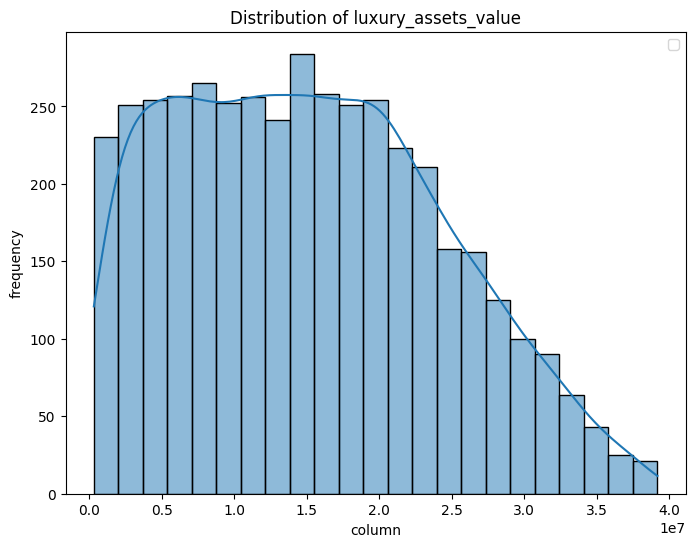

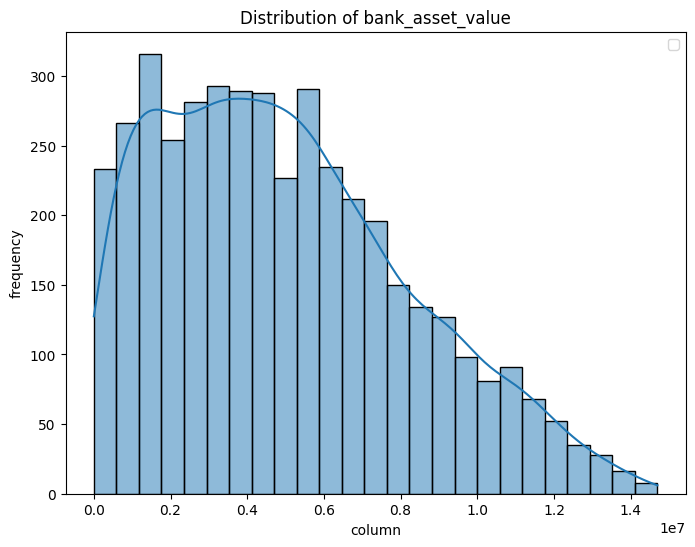

In [231]:
#Distribution of numerical variables (using histogram)

for col in numerical:
  if col != 'loan_id':
    plt.figure(figsize=(8,6))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel("column")
    plt.ylabel("frequency")
    plt.legend()
    plt.show()

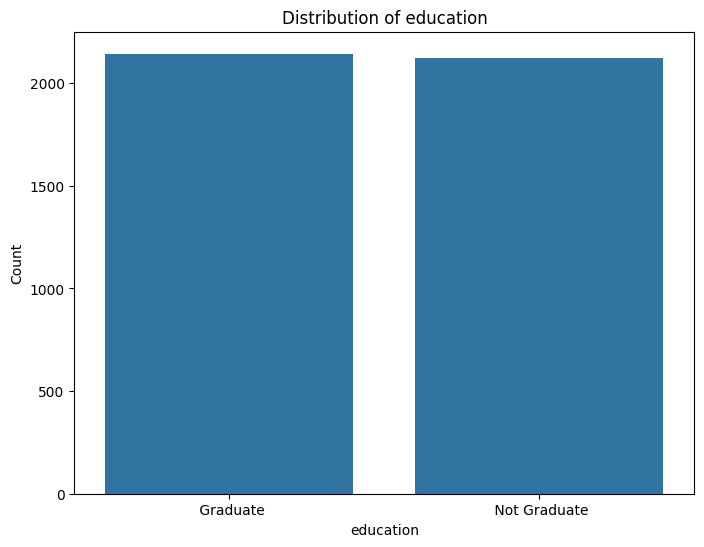

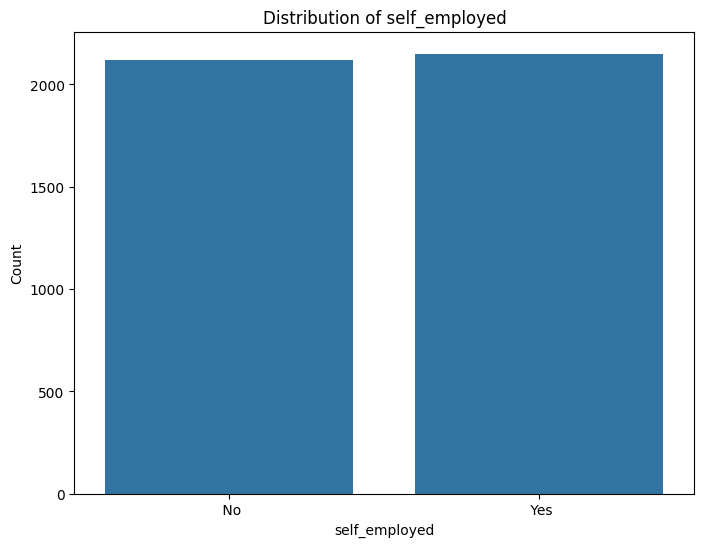

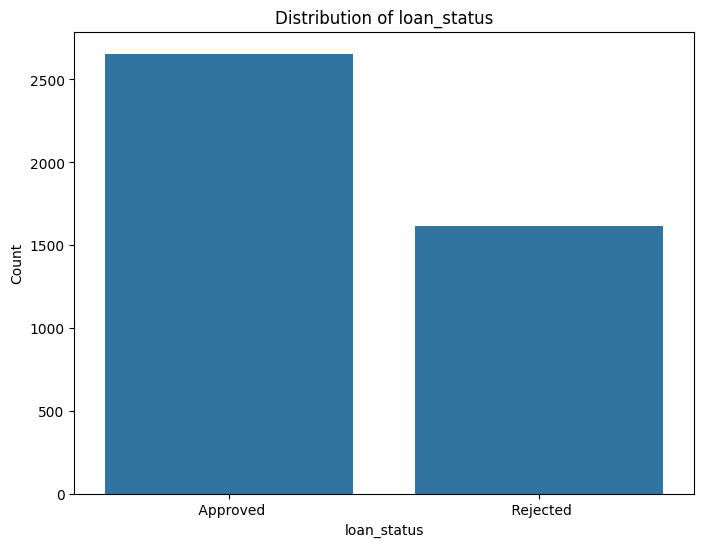

In [232]:
# Count plots for categorical variables

for col in categorical:
  plt.figure(figsize=(8,6))
  sns.countplot(x=df[col])
  plt.title(f"Distribution of {col}")
  plt.xlabel(col)
  plt.ylabel("Count")
  plt.show()

Text(0.5, 1.0, 'correlation heatmap')

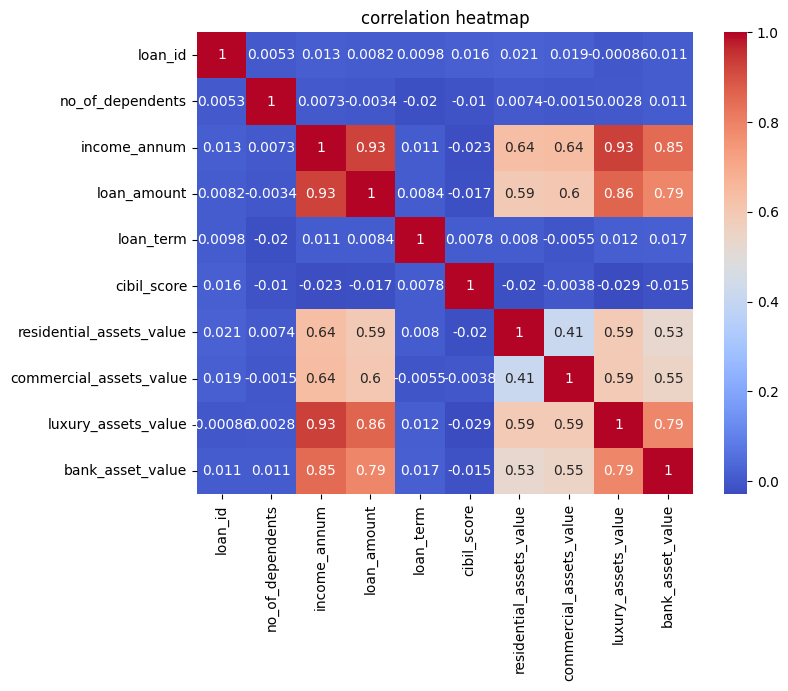

In [233]:
# Correlation Heatmap

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("correlation heatmap")

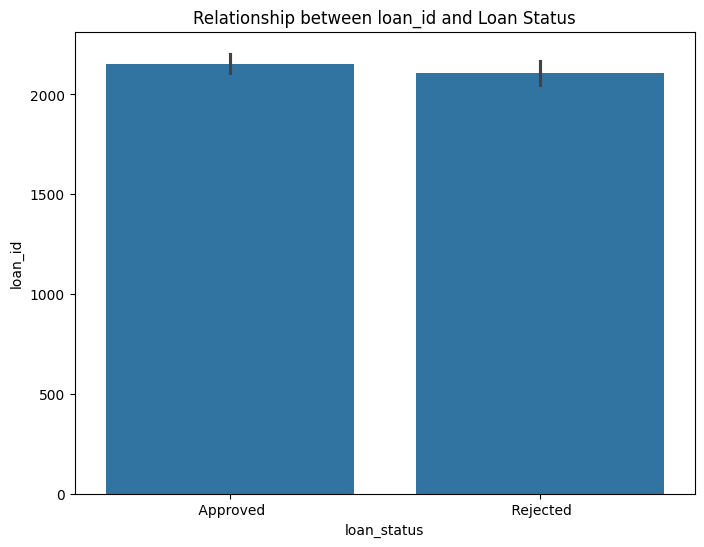

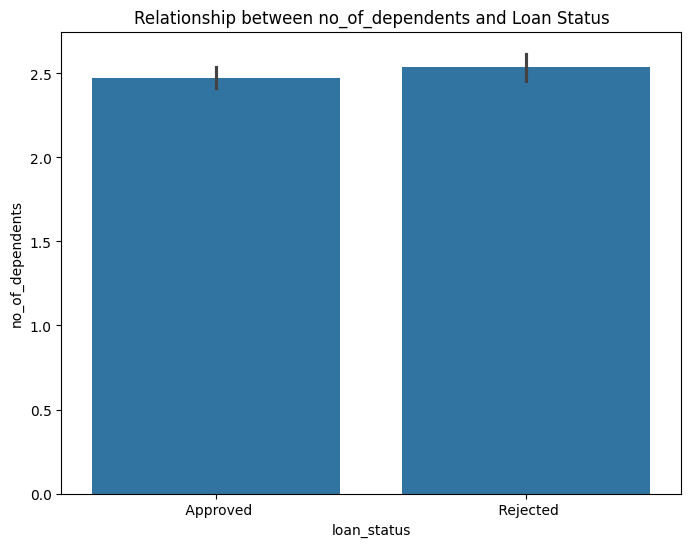

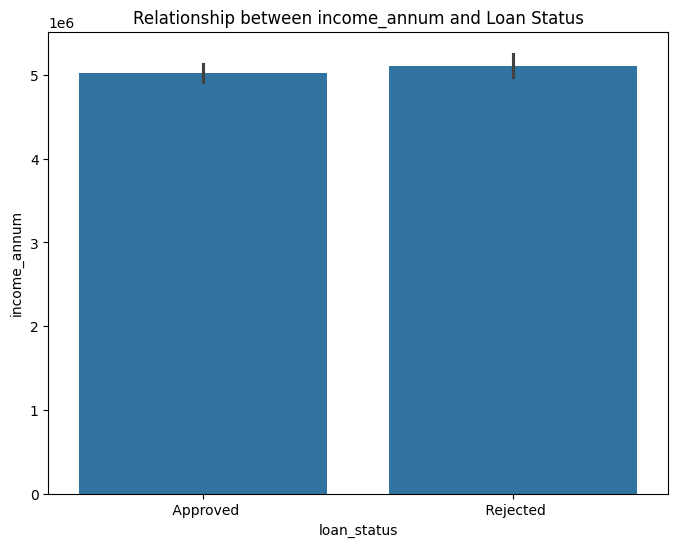

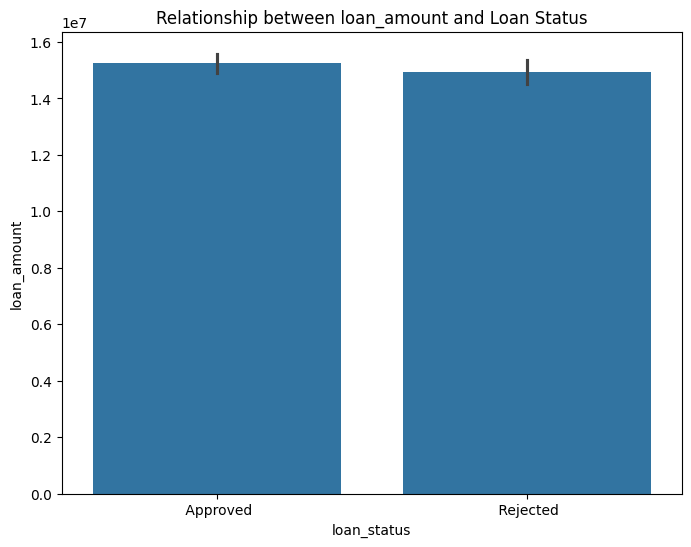

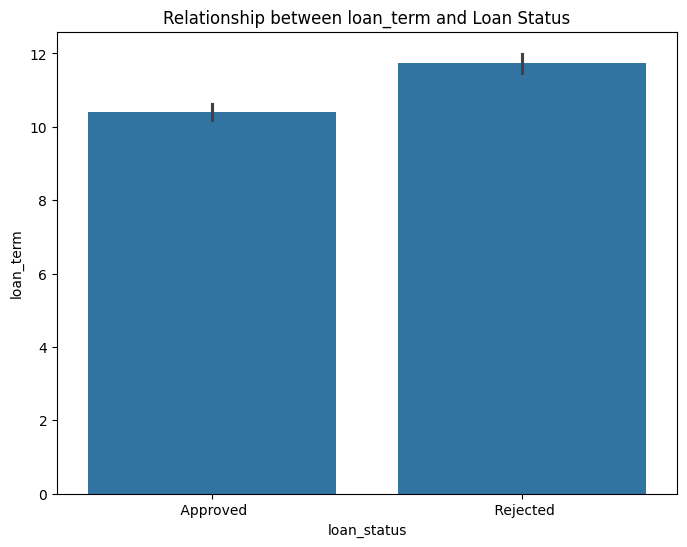

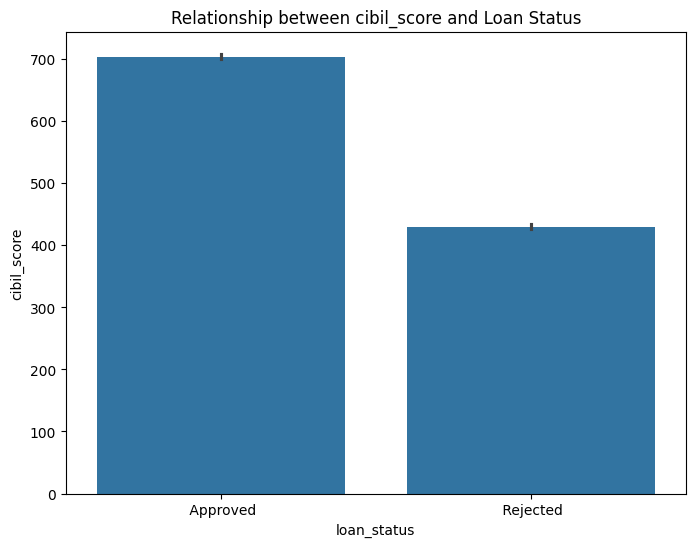

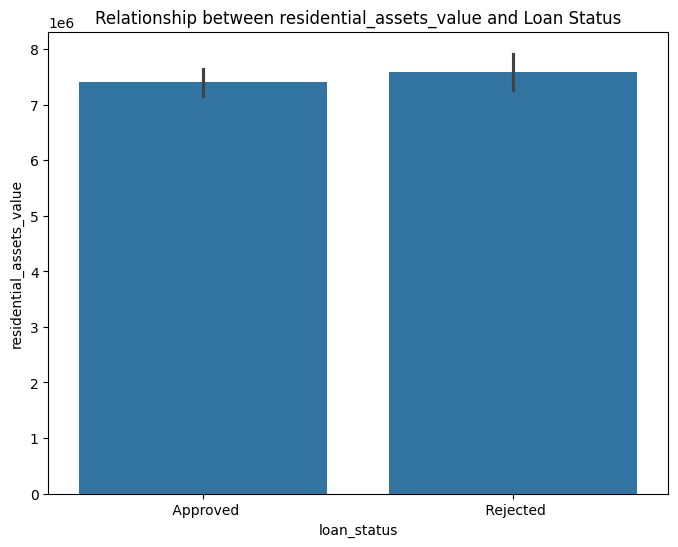

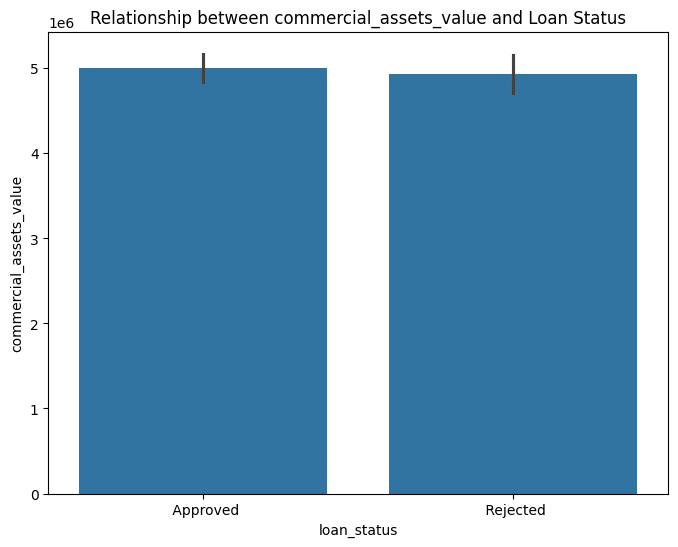

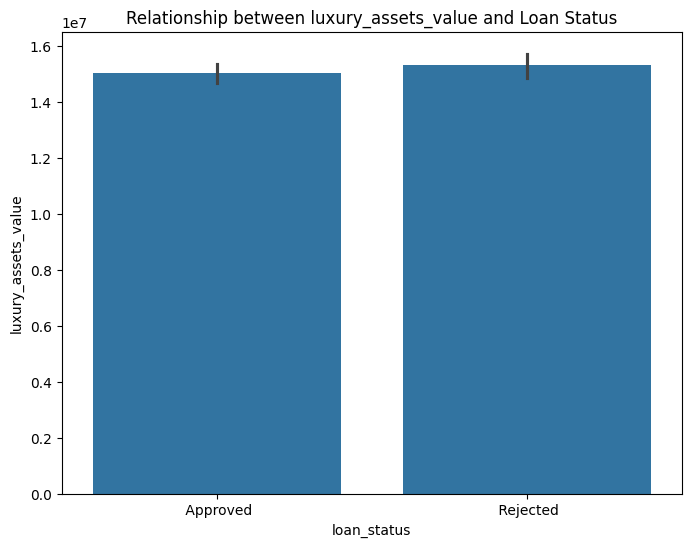

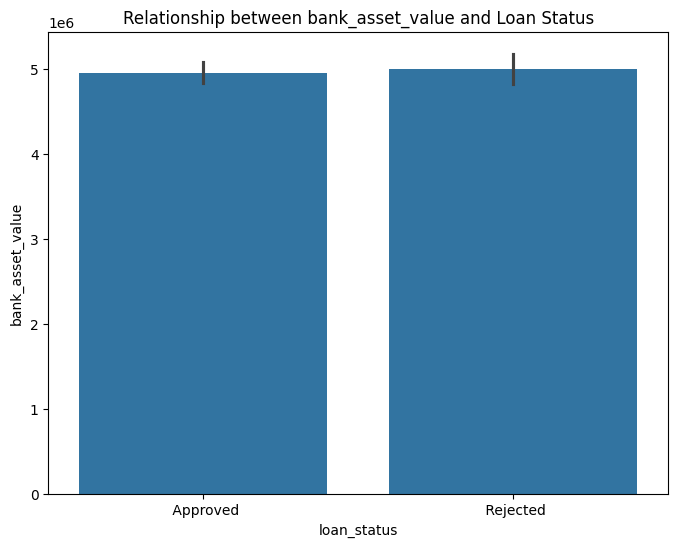

In [234]:
# Relationship between important features and Loan Status

for col in numerical:
  plt.figure(figsize=(8, 6))
  sns.barplot(x='loan_status', y=col, data=df)
  plt.title(f"Relationship between {col} and Loan Status")
  plt.xlabel("loan_status")
  plt.ylabel(col)
  plt.show()


In [235]:
#Write your observations after every visualization. need help

In [236]:
# Feature Selection

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
df[numerical] = sc.fit_transform(df[numerical])



In [237]:
#Remove the unnecessary columns (if required)
df.drop('loan_id', axis=1, inplace=True)

In [238]:
# Encode categorical variables
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in categorical:
  df[col] = le.fit_transform(df[col])

print(df.head())

   no_of_dependents  education  self_employed  income_annum  loan_amount  \
0         -0.294102          0              0      1.617979     1.633052   
1         -1.473548          1              1     -0.341750    -0.324414   
2          0.295621          0              0      1.439822     1.610933   
3          0.295621          0              0      1.119139     1.721525   
4          1.475067          1              1      1.689242     1.002681   

   loan_term  cibil_score  residential_assets_value  commercial_assets_value  \
0   0.192617     1.032792                 -0.780058                 2.877289   
1  -0.508091    -1.061051                 -0.733924                -0.631921   
2   1.594031    -0.544840                 -0.057300                -0.107818   
3  -0.508091    -0.771045                  1.649637                -0.381263   
4   1.594031    -1.264055                  0.757724                 0.735304   

   luxury_assets_value  bank_asset_value  loan_status  
0     

In [239]:
x = df.iloc[:, : -1].values
y = df.iloc[:, -1].values

print(x)
# print([x, y])

[[-0.2941017   0.          0.         ...  2.877289    0.83202837
   0.93030441]
 [-1.4735476   1.          1.         ... -0.63192107 -0.69499321
  -0.51593638]
 [ 0.29562125  0.          0.         ... -0.10781827  1.99651964
   2.40731629]
 ...
 [-0.2941017   1.          0.         ...  1.69236092  0.3266831
   0.71490685]
 [-0.88382465  1.          0.         ... -0.97372725 -0.11274758
   0.25334064]
 [-0.88382465  0.          0.         ...  1.55563845  2.26017804
   2.16114764]]


In [240]:
#Separate Features (X) and Target (Y)

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)



In [241]:
# Decision Tree model

from sklearn.tree import DecisionTreeClassifier
Classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 42)
Classifier.fit(x_train, y_train)


DecisionTreeClassifier(criterion='entropy', random_state=42)

In [242]:
y_pred = Classifier.predict(x_test)
print(np.concatenate((y_pred.reshape(-1, 1), y_test.reshape(-1, 1)), axis = 1))

[[1 1]
 [0 0]
 [1 1]
 ...
 [0 0]
 [1 1]
 [1 1]]


In [243]:
# Accuracy Score
# Confusion Matrix
# Precision
# Recall
# F1 Score
# Classification Report

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:", cm)
print(f"accuracy_score:", accuracy_score(y_test, y_pred))
print(f"precision_score:", precision_score(y_test, y_pred))
print(f"recall_score:", recall_score(y_test, y_pred))
print(f"f1_score:", f1_score(y_test, y_pred))
print(f"classification_report:", classification_report(y_test, y_pred))

Confusion Matrix: [[528   8]
 [  6 312]]
accuracy_score: 0.9836065573770492
precision_score: 0.975
recall_score: 0.9811320754716981
f1_score: 0.9780564263322884
classification_report:               precision    recall  f1-score   support

           0       0.99      0.99      0.99       536
           1       0.97      0.98      0.98       318

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



In [244]:
#Random Forest model

from sklearn.ensemble import RandomForestClassifier
Classifier = RandomForestClassifier(n_estimators=100, criterion='entropy', random_state=42)
Classifier.fit(x_train, y_train)
y_pred = Classifier.predict(x_test)
print(np.concatenate((y_pred.reshape(len(y_pred), 1), y_test.reshape(len(y_test), 1)), 1))


[[1 1]
 [0 0]
 [1 1]
 ...
 [0 0]
 [1 1]
 [1 1]]


In [245]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:\n{cm}")
print(f"\nAccuracy Score: {accuracy_score(y_test, y_pred)}")
print(f"\nPrecision Score: {precision_score(y_test, y_pred)}")
print(f"\nRecall Score: {recall_score(y_test, y_pred)}")
print(f"\nF1 Score: {f1_score(y_test, y_pred)}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

Confusion Matrix:
[[528   8]
 [ 12 306]]

Accuracy Score: 0.9765807962529274

Precision Score: 0.9745222929936306

Recall Score: 0.9622641509433962

F1 Score: 0.9683544303797469

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       536
           1       0.97      0.96      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.97       854
weighted avg       0.98      0.98      0.98       854



In [253]:
# Support Vector Machine (SVM) model

from sklearn.svm import SVC
import numpy as np
Classifier = SVC(kernel = 'linear', random_state = 42)
Classifier.fit(x_train, y_train)
y_pred = Classifier.predict(x_test)
print(np.concatenate((y_pred.reshape(len(y_pred), 1), y_test.reshape(len(y_test), 1)), 1))

[[1 1]
 [0 0]
 [1 1]
 ...
 [0 0]
 [1 1]
 [0 1]]


In [254]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix: \n{cm}")
print(f"\nAccuracy Score: {accuracy_score(y_test, y_pred)}")
print(f"\nPrecision Score: {precision_score(y_test, y_pred)}")
print(f"\nRecall Score: {recall_score(y_test, y_pred)}")
print(f"\nF1 Score: {f1_score(y_test, y_pred)}")
print(f"\nClassification Report: \n{classification_report(y_test, y_pred)}")

Confusion Matrix: 
[[495  41]
 [ 30 288]]

Accuracy Score: 0.9168618266978923

Precision Score: 0.8753799392097265

Recall Score: 0.9056603773584906

F1 Score: 0.8902627511591963

Classification Report: 
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       536
           1       0.88      0.91      0.89       318

    accuracy                           0.92       854
   macro avg       0.91      0.91      0.91       854
weighted avg       0.92      0.92      0.92       854



**All below points were fetched from Gemini. Need more understanding on this section**

## Model Performance Comparison

Let's summarize the performance of each model based on the accuracy scores obtained:

*   **Decision Tree Classifier:** 0.9836
*   **Random Forest Classifier:** 0.9766
*   **Support Vector Machine (SVM) Classifier:** 0.9169

From this, the Decision Tree Classifier appears to be the best-performing model based on accuracy, closely followed by the Random Forest Classifier.

## Task 7 – Business Interpretation

### Which model performed the best?
Based on the accuracy scores, the **Decision Tree Classifier** performed the best with an accuracy of approximately 98.36%. The Random Forest Classifier was a close second with 97.66% accuracy, while the SVM Classifier had a lower accuracy of 91.69%.

### Which features appear to influence loan approval the most?
To determine the most influential features, we would typically look at feature importance scores, especially from tree-based models like Decision Tree and Random Forest. We haven't explicitly calculated and displayed these, but generally, features like `cibil_score`, `income_annum`, `loan_amount`, and various asset values (`residential_assets_value`, `commercial_assets_value`, `luxury_assets_value`, `bank_asset_value`) are strong indicators of a borrower's financial health and repayment capacity, and thus are highly likely to influence loan approval.

### Should the company completely rely on the model's predictions? Why?
No, the company should **not completely rely** on the model's predictions for several reasons:

1.  **Bias:** Models can inherit biases present in the training data, leading to unfair or discriminatory decisions for certain groups.
2.  **Explainability:** While the Decision Tree is more interpretable than a "black box" model, understanding the exact reasoning for every prediction can be complex. For critical decisions like loan approval, transparency is crucial.
3.  **Dynamic Environment:** Economic conditions, regulations, and individual financial situations are constantly changing. A model trained on past data might not accurately reflect current or future scenarios.
4.  **Edge Cases/Novel Situations:** The model might perform poorly on applicants with unique financial profiles or in situations not well represented in the training data.
5.  **Ethical Considerations:** Relying solely on an algorithm for loan approval can lead to ethical dilemmas and potential legal challenges if not properly audited and monitored.

The model should be used as a powerful tool to assist human loan officers, providing data-driven insights and accelerating the decision-making process, but human oversight and judgment are essential.

### What are the limitations of the current model?
1.  **Data Scope:** The model is trained on a specific dataset. Its performance might not generalize well to a broader population or different geographical regions if the training data isn't representative.
2.  **Feature Engineering:** We relied on the provided features. More advanced feature engineering (e.g., debt-to-income ratio, age of borrower, etc.) could potentially improve performance.
3.  **Interpretability vs. Performance Trade-off:** While the Decision Tree is somewhat interpretable, for highly complex interactions, it might still be hard to pinpoint the exact reasons for a denial, for example.
4.  **Static Model:** The current model is static. It doesn't learn or adapt over time with new data unless retrained.
5.  **Lack of External Data:** Incorporating external economic indicators or credit bureau data could significantly enhance the model's predictive power.

### How can the model be improved in the future?
1.  **Feature Engineering:** Explore creating new features from existing ones (e.g., ratios, aggregations) that could provide more predictive power.
2.  **Advanced Models:** Experiment with more sophisticated ensemble methods (e.g., Gradient Boosting, XGBoost, LightGBM) or neural networks, which can often capture more complex patterns.
3.  **Hyperparameter Tuning:** Conduct more extensive hyperparameter tuning using techniques like GridSearchCV or RandomizedSearchCV for all models.
4.  **Cross-Validation:** Implement k-fold cross-validation during training to get a more robust estimate of model performance and reduce overfitting.
5.  **External Data Integration:** Incorporate additional relevant data sources, such as credit scores from bureaus, economic indicators, or alternative data, if available and permissible.
6.  **Explainable AI (XAI):** Employ XAI techniques (e.g., SHAP, LIME) to better understand feature contributions and model decisions, improving trust and transparency.
7.  **Bias Detection and Mitigation:** Implement methods to detect and mitigate potential biases in the model's decisions, ensuring fairness.
8.  **Regular Monitoring and Retraining:** Set up a system for continuous monitoring of model performance in production and periodic retraining with new data to keep it relevant and accurate.

## Task 8 – Conclusion

### Business Problem
This project addressed the business problem of automating and improving the efficiency and accuracy of loan approval decisions. The goal was to build a predictive model that could assess the likelihood of loan approval based on various applicant features, thereby reducing manual effort, minimizing risk, and ensuring consistency in lending.

### Approach Followed
The approach involved several key stages:
1.  **Data Loading and Initial Inspection:** The `loan_approval_dataset.csv` was loaded, and basic checks were performed on its structure, dimensions, and column names.
2.  **Data Cleaning and Preprocessing:** This included handling missing values (none found in this dataset), cleaning column names, encoding categorical features using `LabelEncoder`, and scaling numerical features using `StandardScaler`. The `loan_id` column was dropped as it was not relevant for prediction.
3.  **Exploratory Data Analysis (EDA):** Insights were gained through descriptive statistics, distributions of numerical and categorical variables (histograms, count plots), and correlation analysis (heatmap). Relationships between features and the `loan_status` were also explored.
4.  **Model Training and Evaluation:** The data was split into training and testing sets. Three different machine learning models were trained and evaluated: Decision Tree Classifier, Random Forest Classifier, and Support Vector Machine (SVM) Classifier. Each model's performance was assessed using a confusion matrix, accuracy, precision, recall, F1-score, and a classification report.

### Best-Performing Model
The **Decision Tree Classifier** emerged as the best-performing model in this analysis, achieving the highest accuracy score.

### Final Accuracy Obtained
The final accuracy obtained by the best-performing model (Decision Tree Classifier) was approximately **98.36%**.

### Business Impact of the Solution
The implementation of such a predictive model can have a significant positive business impact:
*   **Increased Efficiency:** Automates a large part of the loan approval process, freeing up human resources for more complex tasks.
*   **Reduced Risk:** By accurately predicting loan defaults, the model can help mitigate financial risks for the lending institution.
*   **Improved Consistency:** Ensures consistent and objective decision-making, reducing human bias and variability in approvals.
*   **Faster Decisions:** Accelerates the loan approval timeline, improving customer satisfaction.
*   **Cost Savings:** Reduces operational costs associated with manual review and potential losses from risky loans.

Overall, this solution provides a robust framework for data-driven loan approval, contributing to more informed and efficient business operations.